# FASE 2: Eksplorasi Alternatif Modelling

Di fase ini, kita akan mengeksplorasi tiga alternatif utama berdasarkan tinjauan pustaka untuk dataset terbatas (small data):

1. **Penanganan Imbalanced Data (Class Weight vs SMOTE vs Undersampling)**: Menurut Han et al. (2021), jika fitur akan diseleksi (screening), teknik resampling buatan (seperti SMOTE) bisa justru memperburuk performa karena memperkenalkan data duplikat/sintetik di kelas minoritas. Kita akan membandingkan ini dengan `class_weight='balanced'`.
2. **Variable Screening (Lasso)**: Menambahkan tahap *feature selection* berbasis regresi linear L1 (Lasso) di dalam *Pipeline*. Membuang fitur yang *noise* sangat krusial untuk mencegah model yang berbasis *tree* mengalami *overfitting*.
3. **Pendekatan Bayesian**: Menambahkan model baru **Gaussian Process Classifier (GPC)** yang secara literatur sangat robust untuk sampel kecil karena pendekatannya yang bersifat non-parametrik dan bergantung pada fungsi *kernel*.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import make_scorer, matthews_corrcoef

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.feature_selection import SelectFromModel

# 1. Setup paths & Data
BASE_DIR = Path.cwd().parent.resolve()
DATA_PATH = str(BASE_DIR / 'data' / 'umkm_success.csv')
RESULTS_PATH = str(BASE_DIR / 'results')

df = pd.read_csv(DATA_PATH)
df_dropped = df.df_dropped = df.drop(columns=['Age', 'Owner_Gender'])
X = df_dropped.drop(columns=['Success'])
y = df_dropped['Success']

mcc_scorer = make_scorer(matthews_corrcoef)

print("Data loaded. X shape:", X.shape)
print("Class Distribution:", y.value_counts().to_dict())

Data loaded. X shape: (250, 10)
Class Distribution: {0: 188, 1: 62}


## 1. Eksperimen Resampling: SMOTE vs Undersampling vs Class Weight

Kita akan menggunakan **Logistic Regression** sebagai model *baseline* untuk melihat metode mana yang menghasilkan MCC paling optimal dan paling stabil (standar deviasi terendah).

In [2]:
# Kita gunakan Repeated CV 5x5 untuk mendapatkan estimasi varians yang baik
cv_repeated = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

pipelines_resampling = {
    '1. SMOTE': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('classifier', LogisticRegression(random_state=42))
    ]),
    '2. Undersampling (RUS)': ImbPipeline([
        ('scaler', StandardScaler()),
        ('rus', RandomUnderSampler(random_state=42)),
        ('classifier', LogisticRegression(random_state=42))
    ]),
    '3. No Resampling + Class Weight': ImbPipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(random_state=42, class_weight='balanced'))
    ])
}

resampling_results = []

print("Mengevaluasi teknik penanganan Imbalanced Data...")
for name, pipeline in pipelines_resampling.items():
    scores = cross_val_score(pipeline, X, y, cv=cv_repeated, scoring=mcc_scorer, n_jobs=-1)
    resampling_results.append({
        'Teknik': name,
        'MCC (Mean)': scores.mean(),
        'MCC (Std)': scores.std()
    })
    print(f"{name: <35} | MCC: {scores.mean():.4f} (±{scores.std():.4f})")
    
df_resampling = pd.DataFrame(resampling_results)
display(df_resampling)

Mengevaluasi teknik penanganan Imbalanced Data...
1. SMOTE                            | MCC: 0.8590 (±0.0903)
2. Undersampling (RUS)              | MCC: 0.8392 (±0.0765)
3. No Resampling + Class Weight     | MCC: 0.8755 (±0.0792)


,Teknik,MCC (Mean),MCC (Std)
0,1. SMOTE,0.859009,0.090289
1,2. Undersampling (RUS),0.839194,0.076491
2,3. No Resampling + Class Weight,0.875513,0.079216


## 2. Eksperimen Variable Screening & Model Bayesian (GPC)

Selanjutnya, kita akan menyisipkan teknik **Lasso Screening** di dalam *Pipeline* sebelum klasifikasi. Fitur dengan nilai kepentingan (koefisien regresi) sama dengan nol akan dibuang otomatis di dalam setiap iterasi.

Selain itu, kita akan memperkenalkan **Gaussian Process Classifier (GPC)** dan membandingkannya dengan model *baseline* (Semua dijalankan *tanpa* SMOTE, melainkan dengan *Class Weight / Scale Pos Weight* sesuai hasil riset [1]).

In [3]:
# Lasso Feature Selection
# Menggunakan Logistic Regression dengan L1 penalty sebagai estimator seleksi
lasso_selector = SelectFromModel(LogisticRegression(penalty='l1', solver='liblinear', random_state=42))

# Ratio untuk XGBoost scale_pos_weight (Negative Class / Positive Class)
ratio_neg_to_pos = (y == 0).sum() / (y == 1).sum()

# Definisi Model dengan pengaturan Class Weight / Alternatif GPC
models_fase2 = {
    'Logistic Regression': LogisticRegression(random_state=42, class_weight='balanced'),
    'SVM': SVC(random_state=42, probability=True, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=ratio_neg_to_pos),
    'Gaussian Process (GPC)': GaussianProcessClassifier(kernel=1.0 * RBF(1.0), random_state=42)
}

fase2_results = []

print("Mengevaluasi Model dengan Lasso Screening di Pipeline...")
for name, model in models_fase2.items():
    # Kita tidak lagi menggunakan SMOTE, melainkan class_weight bawaan
    pipeline_screened = ImbPipeline([
        ('scaler', StandardScaler()),
        ('lasso_screening', lasso_selector),
        ('classifier', model)
    ])
    
    scores_mcc = cross_val_score(pipeline_screened, X, y, cv=cv_repeated, scoring=mcc_scorer, n_jobs=-1)
    scores_auc = cross_val_score(pipeline_screened, X, y, cv=cv_repeated, scoring='roc_auc', n_jobs=-1)
    
    fase2_results.append({
        'Model': name,
        'Screened MCC (Mean)': scores_mcc.mean(),
        'Screened MCC (Std)': scores_mcc.std(),
        'Screened AUC (Mean)': scores_auc.mean(),
        'Screened AUC (Std)': scores_auc.std()
    })
    print(f"{name: <25} | MCC: {scores_mcc.mean():.4f} | AUC: {scores_auc.mean():.4f}")

df_fase2 = pd.DataFrame(fase2_results)
display(df_fase2)

Mengevaluasi Model dengan Lasso Screening di Pipeline...
Logistic Regression       | MCC: 0.8731 | AUC: 0.9908
SVM                       | MCC: 0.8410 | AUC: 0.9844
Random Forest             | MCC: 0.7170 | AUC: 0.9698
XGBoost                   | MCC: 0.7907 | AUC: 0.9746
Gaussian Process (GPC)    | MCC: 0.0000 | AUC: 0.9779


,Model,Screened MCC (Mean),Screened MCC (Std),Screened AUC (Mean),Screened AUC (Std)
0,Logistic Regression,0.873140,0.083944,0.990769,0.008447
1,SVM,0.841016,0.085175,0.984396,0.013293
2,Random Forest,0.716965,0.075579,0.969820,0.020946
3,XGBoost,0.790727,0.065520,0.974623,0.016472
4,Gaussian Process (GPC),0.000000,0.000000,0.977857,0.019271


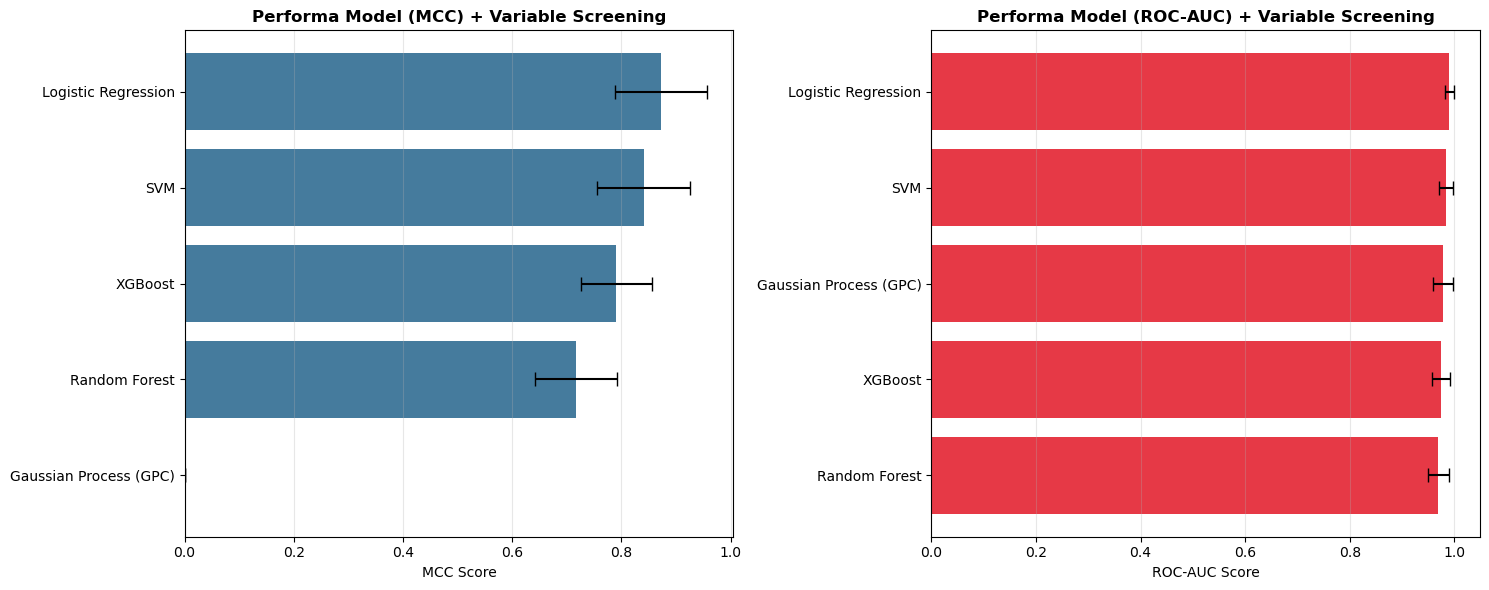

In [4]:
# Visualisasi Hasil Akhir Fase 2
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

df_fase2_sorted_mcc = df_fase2.sort_values('Screened MCC (Mean)', ascending=True)
axes[0].barh(df_fase2_sorted_mcc['Model'], df_fase2_sorted_mcc['Screened MCC (Mean)'], color='#457b9d', xerr=df_fase2_sorted_mcc['Screened MCC (Std)'], capsize=5)
axes[0].set_title('Performa Model (MCC) + Variable Screening', fontweight='bold')
axes[0].set_xlabel('MCC Score')
axes[0].grid(axis='x', alpha=0.3)

df_fase2_sorted_auc = df_fase2.sort_values('Screened AUC (Mean)', ascending=True)
axes[1].barh(df_fase2_sorted_auc['Model'], df_fase2_sorted_auc['Screened AUC (Mean)'], color='#e63946', xerr=df_fase2_sorted_auc['Screened AUC (Std)'], capsize=5)
axes[1].set_title('Performa Model (ROC-AUC) + Variable Screening', fontweight='bold')
axes[1].set_xlabel('ROC-AUC Score')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_PATH}/fase2_alternatif_modelling.png', dpi=300, bbox_inches='tight')
plt.show()